In [125]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [126]:


# Load datasets separately
positive_df = pd.read_csv('/home/eth11/Desktop/positive_metadata_tr.csv')
negative_df = pd.read_csv('/home/eth11/Desktop/negative_metadata_tr.csv')

# Add labels
positive_df['source'] = 'Positive'
negative_df['source'] = 'Negative'

# Combine datasets
df = pd.concat([positive_df, negative_df], ignore_index=True)

# Convert EF column into numeric
df['EF_num'] = df['EF'].str.replace('%', '', regex=False).astype(float)

# Convert AgeString into numeric age
df['Age'] = df['AgeString'].str.extract(r'(\d+)').astype(float)

# Display selected columns
print(df[['EF', 'EF_num', 'AgeString', 'Age', 'source']].head())

# Display first rows
print(df.head())

       EF  EF_num AgeString   Age    source
0  32.99%   32.99   30Years  30.0  Positive
1  31.50%   31.50   70Years  70.0  Positive
2  29.26%   29.26   52Years  52.0  Positive
3  45.78%   45.78   34Years  34.0  Positive
4  48.25%   48.25   27Years  27.0  Positive
   Unnamed: 0            Unique_Id Sex AgeString  BPSys  BPDias  HOHeight  \
0           0  2024.02.13.13.12.11   F   30Years    NaN     NaN       149   
1           1  2024.02.12.10.56.38   F   70Years    NaN     NaN       142   
2           2  2024.02.05.12.27.29   M   52Years    NaN     NaN         0   
3           3  2024.01.30.12.02.25   F   34Years    NaN     NaN         0   
4           4  2024.01.30.11.49.50   F   27Years    NaN     NaN       151   

   LOHeight  HOWeight  LOWeight  ...  LA Vol-I  difS  TR VTI  TR Vmean  \
0         0      62.1         0  ...       NaN   NaN     NaN       NaN   
1         0      47.0         0  ...       NaN   NaN     NaN       NaN   
2         0       0.0         0  ...       NaN   Na

In [127]:
print(df.columns.tolist())

['Unnamed: 0', 'Unique_Id', 'Sex', 'AgeString', 'BPSys', 'BPDias', 'HOHeight', 'LOHeight', 'HOWeight', 'LOWeight', 'WeightKg', 'WeightOz', 'WeightLb', 'BSA', 'LMPIVFType', 'DICOM_LMPIVFDate', 'LMPIVFFlag', 'DICOM_EDCDate', 'UserFetalAgeDays', 'Para', 'Gravida', 'Aborta', 'Ectopics', 'RecentMeasureUnit', 'CurMeasureUnit', 'Fetuses', 'PSA', 'VASC_RBP_SYS', 'VASC_RBP_DIA', 'VASC_LBP_SYS', 'VASC_LBP_DIA', 'VASC_ABI_RIGHT', 'VASC_ABI_LEFT', 'HidePatientInformation', 'PatientRegistration', 'Prefix', 'LatestExam', 'Suffix', 'IS_MEASURE_DATA_EXIST', 'Exam', 'Hospital Name', 'Date', 'Name', 'AGE', 'SEX', 'Referring MD', 'ID', 'BP-DIA', 'BP-SYS', 'Height', 'Weight', 'Indication', 'Comment', 'PV Acc Time', 'TAPSE', 'IVSd', 'LVIDd', 'LVPWd', 'IVSs', 'LVIDs', 'LVPWs', 'LV Mass', 'LV Mass-c', 'LV Mass-I', 'EDV', 'RWT', 'ESV', 'SV', 'EF', 'SI', 'FS', 'AOd', 'LAs diam', 'AOd/LAs', 'LAs/AOd', 'TR Vmax', 'RAP', 'TR PGmax', 'RVSP', 'MV PHT', 'MV DT', 'Dec Slope', 'MV E pt', 'MV A pt', 'MVA(PHT)', 'E/A', 

2. SELECTING 11 REDUIRED FEATURES

#DATA_REPARATION

In [128]:
features = [
    'Age',
    'EF_num',
    'WeightKg',
    'BSA',
    'E/A',
    'A/E',
    'Ea/Aa(m)',
    'E/Ea(m)',
    'LAs/AOd',
    'AOd/LAs',
    'RWT'
]

# Create sub-dataframe


sub_df = df[features + ['source']].dropna()

# Feature matrix
X = sub_df[features]
y = sub_df['source']

# Remaining rows
print("Remaining rows:", len(sub_df))

# Preview
print(sub_df.head())

Remaining rows: 417
     Age  EF_num  WeightKg   BSA   E/A   A/E  Ea/Aa(m)  E/Ea(m)  LAs/AOd  \
4   27.0   48.25      74.0  1.70  1.65  0.61      0.60     7.64     1.53   
6   64.0   33.17      70.0  1.81  1.24  0.80      2.20     9.27     1.32   
7   20.0   46.32      52.7  1.55  1.24  0.80      2.20     9.27     1.69   
9   54.0   29.26      89.0  1.91  1.83  0.55      0.54     8.71     1.71   
11  63.0   14.89      55.0  1.57  4.69  0.21      0.86    12.50     1.78   

    AOd/LAs   RWT    source  
4      0.65  0.38  Positive  
6      0.76  0.24  Positive  
7      0.59  0.23  Positive  
9      0.59  0.48  Positive  
11     0.56  0.26  Positive  


In [129]:
print(X.dtypes)

Age         float64
EF_num      float64
WeightKg    float64
BSA         float64
E/A         float64
A/E         float64
Ea/Aa(m)    float64
E/Ea(m)     float64
LAs/AOd     float64
AOd/LAs     float64
RWT         float64
dtype: object


A2.EXPLORATORY DATA ANALYSIS

In [130]:
# Display descriptive statistics
stats = sub_df.describe()
print(stats)

              Age      EF_num    WeightKg         BSA         E/A         A/E  \
count  417.000000  417.000000  417.000000  417.000000  417.000000  417.000000   
mean    54.856115   51.657314   75.913909    1.805300    1.326811    1.023813   
std     15.694604   17.913341   17.195611    0.217396    0.846196    0.560663   
min     18.000000    9.940000   33.100000    1.130000    0.330000    0.110000   
25%     44.000000   35.740000   64.500000    1.660000    0.730000    0.590000   
50%     56.000000   56.530000   74.200000    1.820000    1.200000    0.840000   
75%     66.000000   67.330000   86.500000    1.940000    1.700000    1.370000   
max     90.000000   84.130000  131.000000    2.470000    9.290000    3.000000   

         Ea/Aa(m)     E/Ea(m)     LAs/AOd     AOd/LAs         RWT  
count  417.000000  417.000000  417.000000  417.000000  417.000000  
mean     0.916091    9.993070    1.472542    0.721367    0.400312  
std      0.463440    4.959065    0.474686    0.161985    0.130836 

Features with very large ranges may dominate clustering.
Outliers can be identified using min and max values.
Features with high standard deviation have large variability.

QN.2 HISTOGRAMS

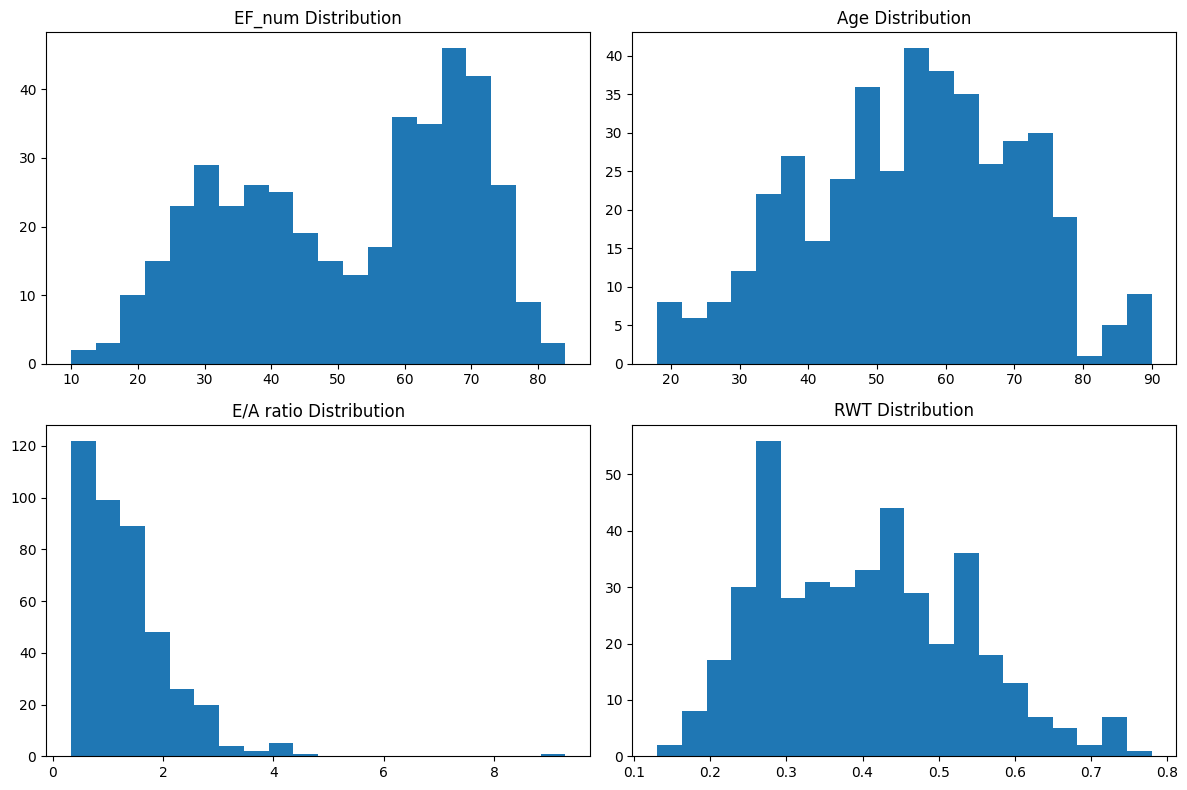

In [131]:
# Create histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(sub_df['EF_num'], bins=20)
axes[0,0].set_title('EF_num Distribution')

axes[0,1].hist(sub_df['Age'], bins=20)
axes[0,1].set_title('Age Distribution')

axes[1,0].hist(sub_df['E/A'], bins=20)
axes[1,0].set_title('E/A ratio Distribution')

axes[1,1].hist(sub_df['RWT'], bins=20)
axes[1,1].set_title('RWT Distribution')

plt.tight_layout()
plt.show()

Right-skewed distributions have long tails toward higher values.
Left-skewed distributions have tails toward lower values.
Strong skewness can affect clustering because distance calculations become uneven.
Scaling helps reduce the impact of skewness.

QN.3 CORRELATION HEATMAP

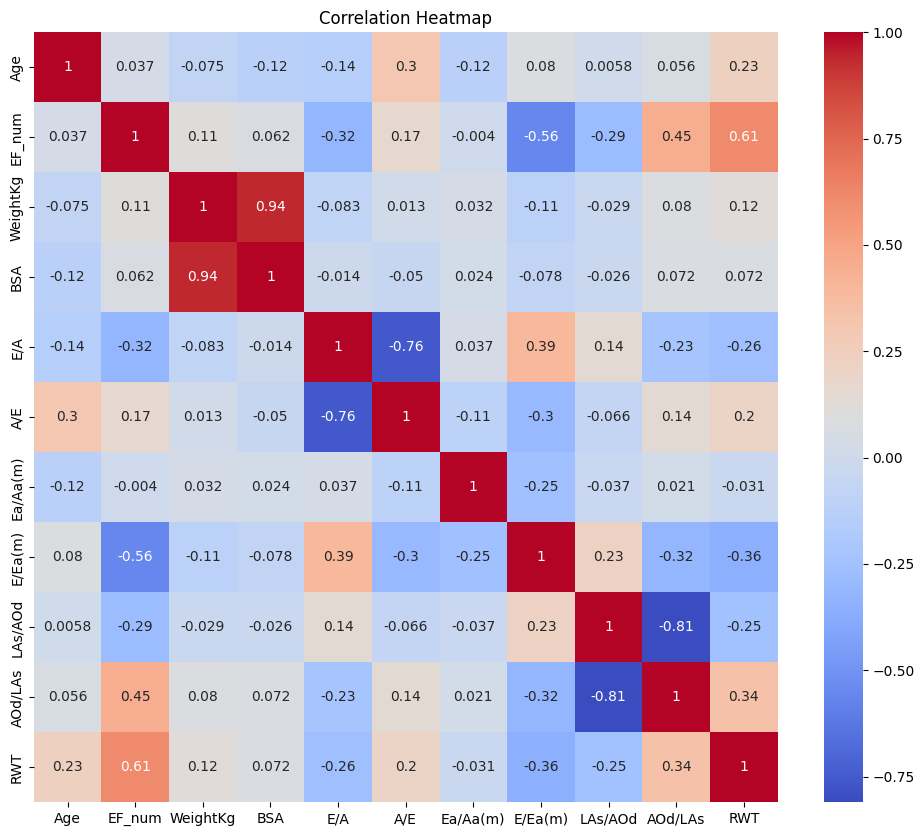

In [132]:
# Compute correlation matrix
corr_matrix = sub_df[features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

E/A ratio and A/E ratio
These are inverse measurements.
Strong negative correlation is expected.
LAs/AOd and AOd/LAs
These are also inverse ratios.
Including both may introduce redundancy.
Highly correlated features may overweight the same information in clustering.
Removing one of them can improve clustering quality and reduce redundancy

A3.PREPROCESSING

Feature scalling is essential in distance-based clustering algorithms like k-means because the algorithm uses Euclidean distance to group data points.standadization ensures that aal features contribute equaly to clustering by transforming them to have a mean of 0 and sd of 1.

In [133]:
# Scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

7. PCA DIMENSIONALITY REDUCTION

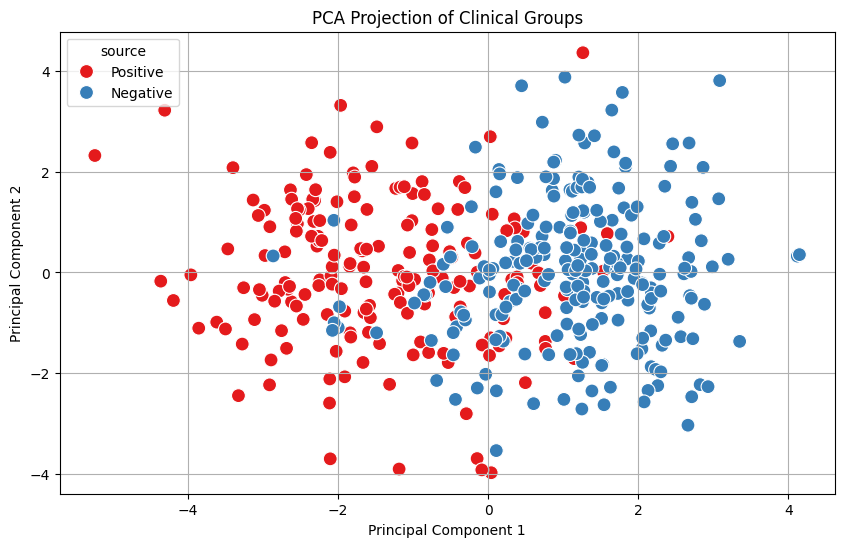

In [134]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=sub_df['source'],
    palette='Set1',
    s=100
)

plt.title('PCA Projection of Clinical Groups')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.grid(True)

plt.show()

1. If groups overlap heavily , they are not visually separable,the clear separation suggest meaningful structural difference between groups. So PCA simplifies visualization while perserving most variance.

#K-MEANS CLUSTERING 


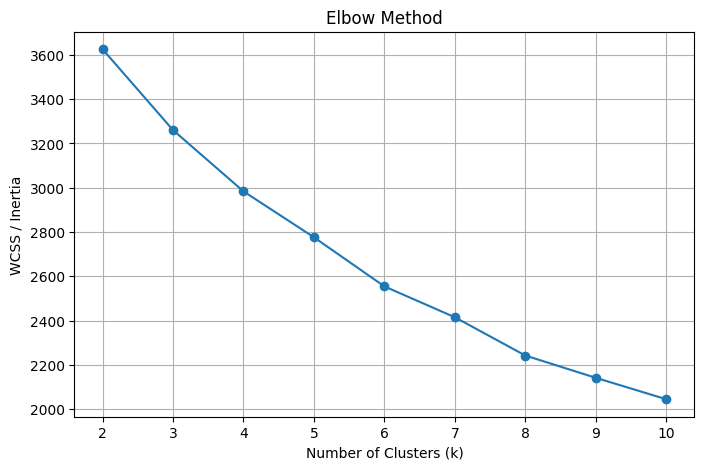

In [135]:

# Elbow Method
inertia_values = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

In [136]:
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print("K =", k, "Score =", score)

K = 2 Score = 0.21529156285454026
K = 3 Score = 0.16825308803923572
K = 4 Score = 0.16401446981355064
K = 5 Score = 0.1560140000703029


The elbow point is where inertia starts decreasing slowly

k = 2, Silhouette Score = 0.2153
k = 3, Silhouette Score = 0.1677
k = 4, Silhouette Score = 0.1640
k = 5, Silhouette Score = 0.1560
k = 6, Silhouette Score = 0.1650
k = 7, Silhouette Score = 0.1541
k = 8, Silhouette Score = 0.1535
k = 9, Silhouette Score = 0.1470
k = 10, Silhouette Score = 0.1468

Best k: 2
Highest Silhouette Score: 0.21529156285454026


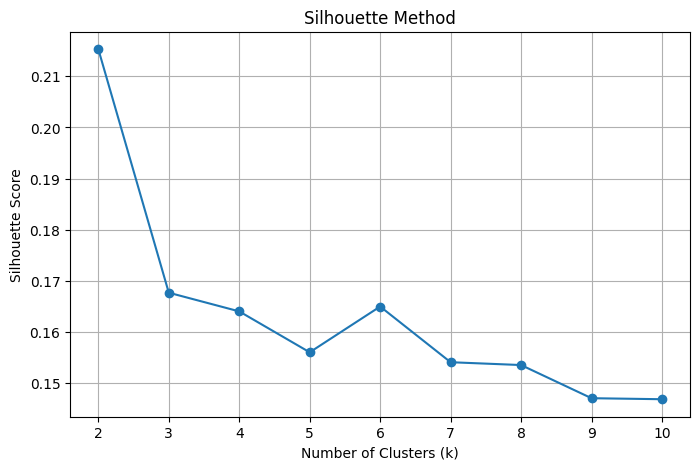

In [137]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Store silhouette scores
silhouette_scores = []

# Range of k values
K_range = range(2, 11)

# Compute scores
for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"k = {k}, Silhouette Score = {score:.4f}")

# Best k
best_k = K_range[np.argmax(silhouette_scores)]

print("\nBest k:", best_k)
print("Highest Silhouette Score:", max(silhouette_scores))

# Plot graph
plt.figure(figsize=(8,5))

plt.plot(K_range, silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')

plt.grid(True)
plt.show()

In [138]:
# Find best k again

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

# Best k
best_k = K_range[np.argmax(silhouette_scores)]

print("Best k:", best_k)
print("Highest Silhouette Score:", max(silhouette_scores))

Best k: 2
Highest Silhouette Score: 0.21529156285454026


higher score indicates better cluster separation

10.elbow method suggest k=2 and silhouette method suggest k=2 , this shows cluster 2 is the best 

#FITTING K-MEANS

11.Fit k-means

In [139]:
# Fit final K-Means model

kmeans = KMeans(
    n_clusters=best_k,
    init='k-means++',
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

# Add labels
sub_df['Cluster'] = clusters

print(sub_df.head())

     Age  EF_num  WeightKg   BSA   E/A   A/E  Ea/Aa(m)  E/Ea(m)  LAs/AOd  \
4   27.0   48.25      74.0  1.70  1.65  0.61      0.60     7.64     1.53   
6   64.0   33.17      70.0  1.81  1.24  0.80      2.20     9.27     1.32   
7   20.0   46.32      52.7  1.55  1.24  0.80      2.20     9.27     1.69   
9   54.0   29.26      89.0  1.91  1.83  0.55      0.54     8.71     1.71   
11  63.0   14.89      55.0  1.57  4.69  0.21      0.86    12.50     1.78   

    AOd/LAs   RWT    source  Cluster  
4      0.65  0.38  Positive        0  
6      0.76  0.24  Positive        0  
7      0.59  0.23  Positive        0  
9      0.59  0.48  Positive        0  
11     0.56  0.26  Positive        0  


12. Visualise clusters in PCA space

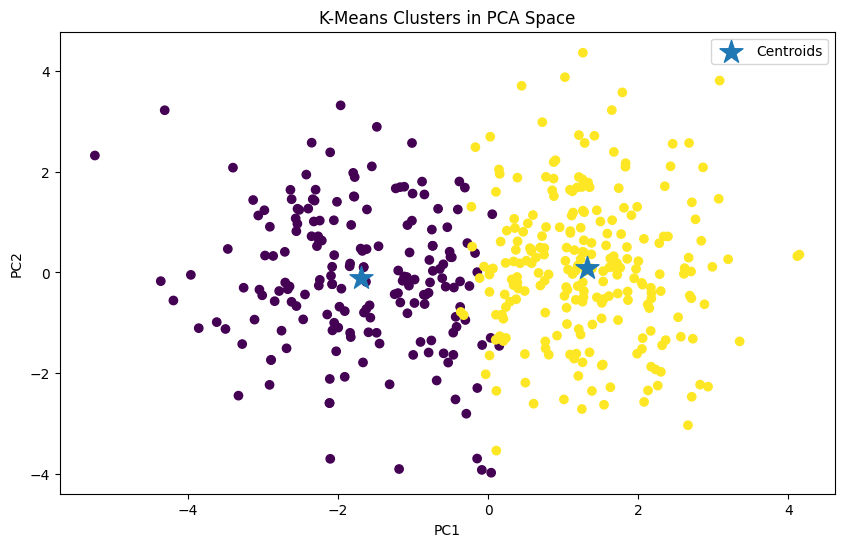

In [140]:
# PCA centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot clusters
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

# Plot centroids
plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    s=300,
    marker='*',
    label='Centroids'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters in PCA Space')
plt.legend()
plt.show()

The points with the same color belongs to same cluster and those stars (centroids) represent center of each cluster. There is ovellaping of cluster which means data are not clear separated which results to small silhouette score 

13.CLUSTER FEATURE MEANS

In [143]:
# Mean values per cluster
cluster_means = sub_df.drop(columns=['source']).groupby('Cluster').mean()

print(cluster_means)

               Age     EF_num   WeightKg       BSA       E/A       A/E  \
Cluster                                                                  
0        54.225275  36.209231  71.576374  1.760824  1.757143  0.824725   
1        55.344681  63.621362  79.273191  1.839745  0.993532  1.178000   

         Ea/Aa(m)    E/Ea(m)   LAs/AOd   AOd/LAs       RWT  
Cluster                                                     
0        0.885549  13.612857  1.721648  0.613626  0.309835  
1        0.939745   7.189660  1.279617  0.804809  0.470383  


HEATMAP Version

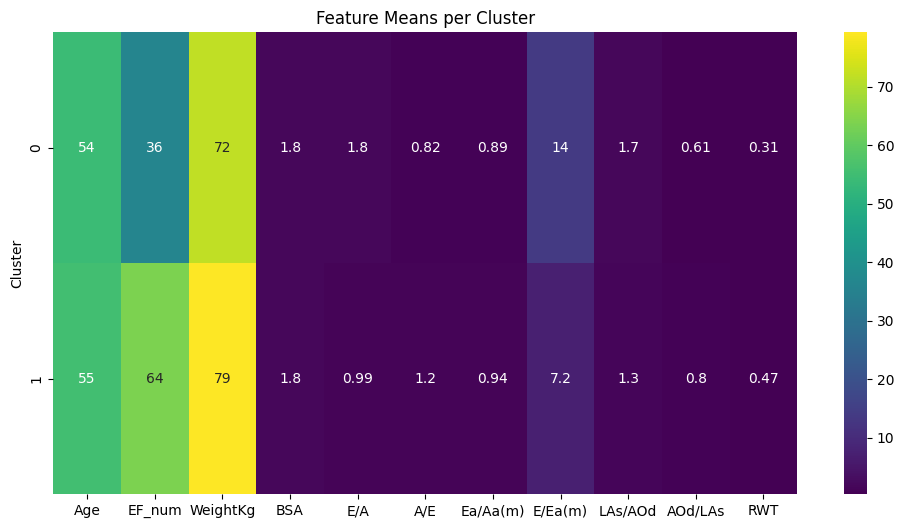

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, annot=True, cmap='viridis')
plt.title('Feature Means per Cluster')
plt.show()

The cluster with the lowest average EF_num may indicate reduced cardiac function and the cluster with higheat E/Ea(m) may indicate elevated filling pressure

SENSITIVITY TO INITIALIZATION

In [ ]:
results = []

for rs in [0, 42, 99]:

    kmeans_random = KMeans(
        n_clusters=best_k,
        init='random',
        n_init=10,
        random_state=rs
    )

    labels = kmeans_random.fit_predict(X_scaled)

    inertia = kmeans_random.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    results.append([
        rs,
        inertia,
        silhouette
    ])

# Create results dataframe
results_df = pd.DataFrame(
    results,
    columns=['Random State', 'Inertia', 'Silhouette Score']
)

print(results_df)

   Random State      Inertia  Silhouette Score
0             0  3625.958903          0.215292
1            42  3625.958903          0.215292
2            99  3625.958903          0.215292


The results did not change , this suggests that the clusters is not affected by random centroid initialization . So model is reliable and data has strong cluster patterns